# Reproduce the paper — every figure and table

*Knowledge Distillation with PySR on the PRIYA suite.* This is the **single** notebook
that regenerates **every figure and table in `oja_template.tex`** from the committed
production run (`results/paper_production_20260630_perz_sobolev_z2.6-4.2/`).

It runs in two tiers, top to bottom:

| tier | needs | reproduces |
|------|-------|-----------|
| **1 — emulator-free** | `requirements-figures.txt` only | Tables 1, 2, 6, 7 + Figs pareto_faithfulness, faithfulness_scorecard, ns_budget_panel, seed_band |
| **2 — GP-backed** | GP emulator (GPy+lyaemu), `data/kodiaq_gp`, the paper's regen_* scripts | Figs pysr_pred_tau0_Ap, pysr_graphs_3.6_dtau0, multid_bestworst + Table 3 |

**Tier-2 cells run automatically if the GP emulator is importable; otherwise they print
the exact command and skip** (the notebook always completes). See `REPRODUCE.md` for the
Tier-2 environment. The figure/table to section map is the final cell.

## 0. Setup — locate everything and detect the GP emulator

In [1]:
import os, sys, subprocess
from pathlib import Path

# Repo root: walk up to the dir containing src/priya_forecast; chdir there.
_root = Path.cwd()
while _root != _root.parent and not (_root / "src" / "priya_forecast").is_dir():
    _root = _root.parent
os.chdir(_root); sys.path.insert(0, "src")

import numpy as np, pandas as pd, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
from priya_forecast import paper_figures as pf

PROD = Path("results/paper_production_20260630_perz_sobolev_z2.6-4.2")
FIG  = PROD / "figures"
SCRATCH = Path("results/_repro_scratch/reproduce_paper"); SCRATCH.mkdir(parents=True, exist_ok=True)
run = pf.load_run()                      # all committed sidecars/JSON (Tier-1)
print("repo:", _root.name, "| run git:", run.seed_band.get("git"), "| z =", run.z)

# ---- Tier-2 environment detection (override the paths via env vars) ----
LYA_EMULATOR = os.environ.get("LYA_EMULATOR", "/home/mfho/student_projects/lya_emulator_full")
FIGREPO      = os.environ.get("FIGREPO", str(_root.parent / "Knowledge-Distillation-using-PySR-with-PRIYA-suite"))
GP_BASEDIR   = "data/kodiaq_gp"

def _have_gp():
    if not Path(GP_BASEDIR).is_dir():
        return False, "GP basedir " + GP_BASEDIR + " missing (build via scripts/prep_kodiaq_gp.py)"
    if not Path(LYA_EMULATOR, "lyaemu").is_dir():
        return False, "lyaemu not at LYA_EMULATOR=" + LYA_EMULATOR
    try:
        import GPy  # noqa: F401
    except Exception as e:
        return False, "GPy not importable (" + str(e) + ")"
    return True, "ok"

HAVE_GP, GP_WHY = _have_gp()
GP_ENV = dict(os.environ, PYTHONPATH="src:" + LYA_EMULATOR,
              PYTHON_JULIAPKG_PROJECT=os.path.expanduser("~/.julia_env"),
              JULIA_DEPOT_PATH=os.path.expanduser("~/.julia"))
print("Tier-2 GP available:", HAVE_GP, "" if HAVE_GP else "(" + GP_WHY + ")")
print("FIGREPO:", FIGREPO, "(exists)" if Path(FIGREPO).is_dir() else "(NOT found — set $FIGREPO)")

def run_regen(args, produces, cwd=None):
    # Run a Tier-2 regen script with the GP env; return the produced Path (or None).
    # If the GP env is missing, print the command and skip (no error).
    printable = " ".join(str(a) for a in args)
    if not HAVE_GP:
        print("[skip: no GP] would run:\n  PYTHONPATH=src:$LYA_EMULATOR python " + printable)
        return None
    print("$ python " + printable)
    r = subprocess.run([sys.executable] + [str(a) for a in args], env=GP_ENV,
                       cwd=cwd or _root, capture_output=True, text=True)
    print("\n".join(r.stdout.strip().splitlines()[-3:]) or "(ok)")
    if r.returncode != 0:
        print(r.stderr[-1500:]); raise RuntimeError("regen failed (exit " + str(r.returncode) + ")")
    return Path(produces) if Path(produces).exists() else None

def show(fig):                            # a Matplotlib Figure (Tier-1) -> inline PNG
    from io import BytesIO
    buf = BytesIO(); fig.savefig(buf, format="png", dpi=130, bbox_inches="tight"); plt.close(fig)
    display(Image(data=buf.getvalue()))

def show_pdf(pdf, fallback_png):
    # Tier-2 regen writes a PDF; convert the FRESH pdf to png (pdftoppm) for inline
    # display, else fall back to the committed reference png.
    pdf = Path(pdf) if pdf else None
    if pdf and pdf.exists():
        stem = pdf.with_suffix("")
        try:
            subprocess.run(["pdftoppm", "-png", "-r", "150", "-singlefile",
                            str(pdf), str(stem)], check=True, capture_output=True)
            png = Path(str(stem) + ".png")
            if png.exists():
                display(Image(filename=str(png))); return
        except Exception:
            pass
    if fallback_png and Path(fallback_png).exists():
        print("(showing committed reference figure)")
        display(Image(filename=str(fallback_png)))

repo: lya1d_priya_forecast | run git: 7aa26af | z = 3.6


Tier-2 GP available: True 
FIGREPO: /home/mfho/Latex/Knowledge-Distillation-using-PySR-with-PRIYA-suite (exists)


---
# Tier 1 — emulator-free (Tables 1/2/6/7 + 4 figures)

Replays committed CSVs/JSON with only numpy/pandas/matplotlib — no GP, PySR, or Julia.

## Table 1 (`tab:param_table`) — the 11 parameters + priors
Single source of truth in `priya_forecast.parameters` (= committed `figures/param_priors_table.txt`).

In [2]:
from priya_forecast.parameters import PARAMS_11D
pd.DataFrame([{"param": p.name, "latex": p.latex, "fid": p.fid,
               "prior_lo": p.prior[0], "prior_hi": p.prior[1]} for p in PARAMS_11D])

,param,latex,fid,prior_lo,prior_hi
0,dtau0,d\tau_0,-0.0090,-0.40,0.250
1,tau0,\tau_0,1.0900,0.75,1.250
2,ns,n_s,0.9830,0.80,1.050
3,Ap,"A_P\,/\,10^{-9}",1.4600,1.20,2.600
4,herei,z^{HeII}_i,4.0000,3.50,4.500
5,heref,z^{HeII}_f,2.7650,2.20,3.200
6,alphaq,\alpha_q,1.7400,1.30,3.000
7,hub,h,0.6880,0.65,0.750
8,omegamh2,\Omega_0 h^2,0.1439,0.14,0.146
9,hireionz,z_{HI},7.2400,6.50,8.000


## Table 6 (`tab:faith_taxonomy`) — derivative-faithfulness taxonomy (headline)
Knee-selected `grad_err`, value vs Sobolev, z=3.6. 9/11 faithful; `hub`+`bhfeedback` resist.

In [3]:
pf.taxonomy(run).round(3)          # tweak the gate: pf.taxonomy(run, gate=0.30)

,param,value_grad_err,sobolev_grad_err,class
0,dtau0,0.009,0.003,faithful
1,tau0,0.006,0.005,faithful
2,ns,0.365,0.160,faithful
3,Ap,0.298,0.155,faithful
4,herei,0.079,0.084,faithful
5,heref,0.105,0.045,faithful
6,alphaq,0.126,0.134,faithful
7,hub,0.986,1.000,resistant
8,omegamh2,0.697,0.063,faithful
9,hireionz,0.266,0.167,faithful


## Table 7 (`tab:per1d_eqs`) — per-parameter equations at the Pareto knee

In [4]:
pf.equations(run, loss="sobolev").round(4)   # loss="value" for the baseline

,param,complexity,loss,grad_err
0,dtau0,19,0.0022,0.0027
1,tau0,20,0.0024,0.0052
2,ns,18,9.7466,0.1603
3,Ap,19,13.5519,0.1546
4,herei,18,0.7172,0.0839
5,heref,20,18.8792,0.0454
6,alphaq,10,27.4870,0.1338
7,hub,10,422.0077,1.0000
8,omegamh2,11,75.0296,0.0630
9,hireionz,19,8.5766,0.1667


## Table 2 (`tab:multid`) — 2D/3D additive-combine best/worst error
Read from the committed `multid_bestworst.csv` (regenerated GP-backed in Tier 2).

In [5]:
pd.read_csv(FIG / "multid_z3.6" / "multid_bestworst.csv", comment="#")

,dim,params,n_varied,mean_pct,p90_pct,max_pct,max_k,gp_sliced,role
0,2D,dtau0-Ap,2,0.7338,1.6954,2.8428,0.00351,NaN,NaN
1,2D,herei-alphaq,2,0.6755,1.6036,8.7006,0.00100,NaN,NaN
2,2D,Ap-ns,2,0.8766,1.9553,4.8282,0.00100,NaN,worst
3,2D,tau0-ns,2,0.3427,0.8186,2.9444,0.00100,NaN,best
4,2D,herei-heref,2,0.3857,0.9570,4.4669,0.00219,NaN,NaN
5,2D,tau0-Ap,2,0.6014,1.4913,3.4500,0.00351,NaN,NaN
6,3D,dtau0-Ap-ns,3,0.8634,1.9272,4.8811,0.00100,NaN,NaN
7,3D,herei-heref-alphaq,3,0.8005,1.8992,9.7892,0.00100,NaN,NaN
8,3D,tau0-Ap-ns,3,0.7894,1.8600,4.9543,0.00100,NaN,best
9,3D,Ap-ns-omegamh2,3,0.9225,2.0573,5.4978,0.00127,NaN,worst


## Fig `pareto_faithfulness` (`fig:pareto_faith`) — the 11-panel Pareto grid

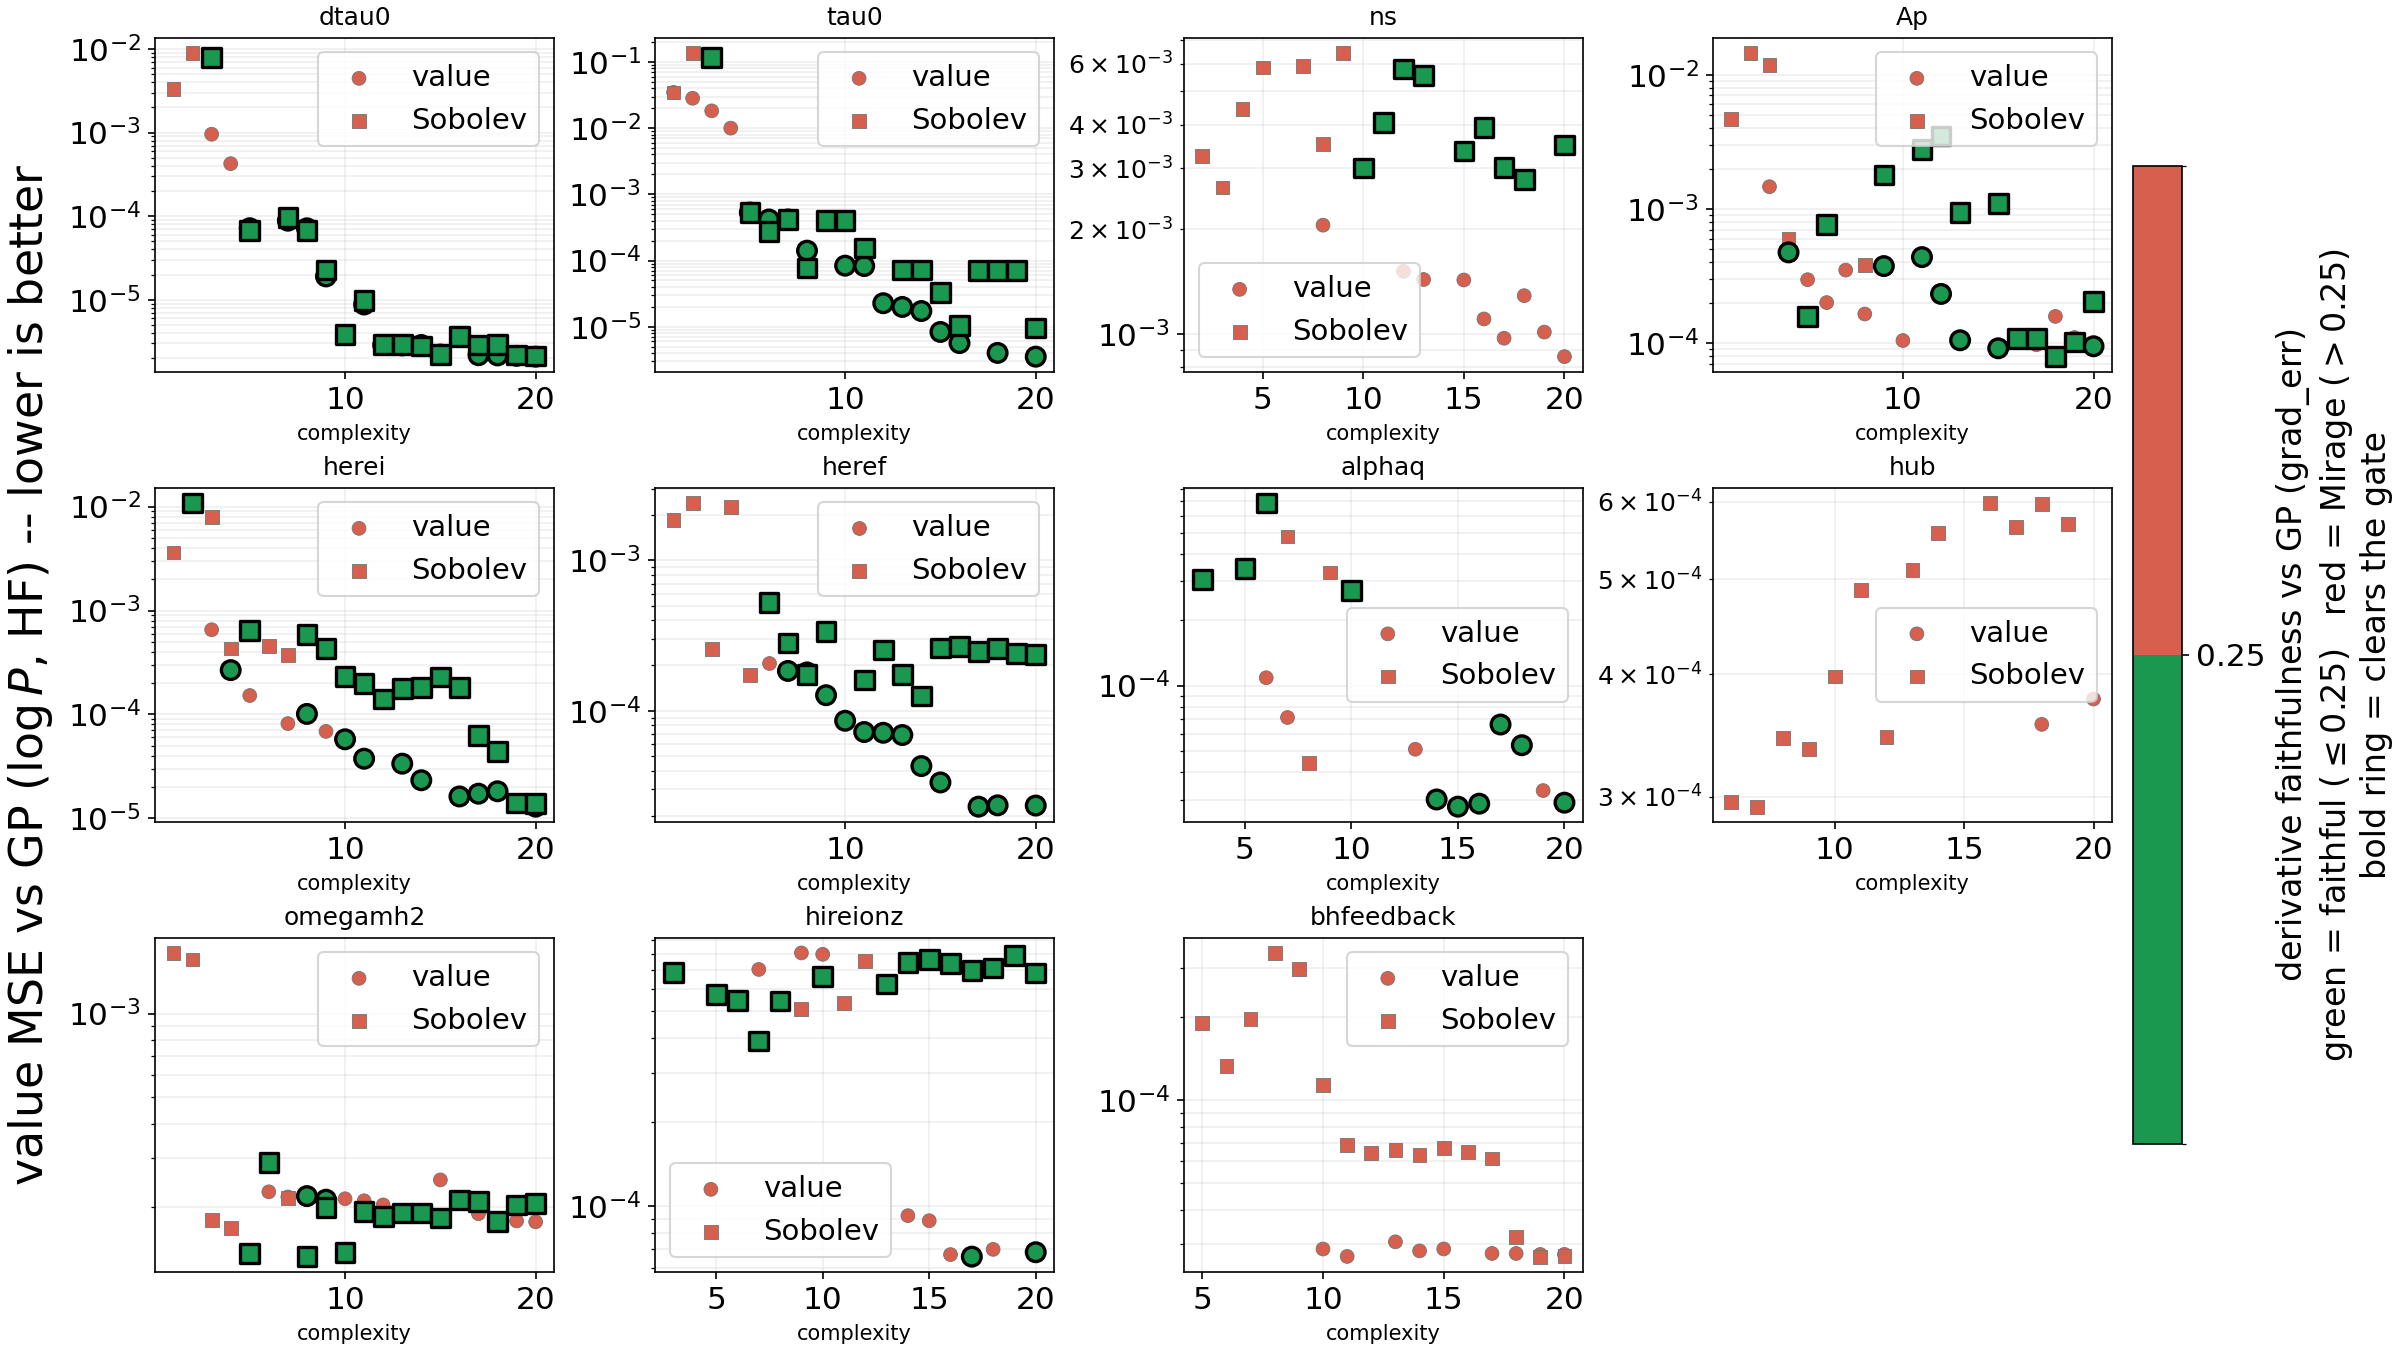

In [6]:
out = str(SCRATCH / "pareto_faithfulness.png")
pf.plot_pareto_faithfulness(run, out)      # writes a grid PNG
display(Image(filename=out))

## Fig `faithfulness_scorecard` (`fig:faith_scorecard`)

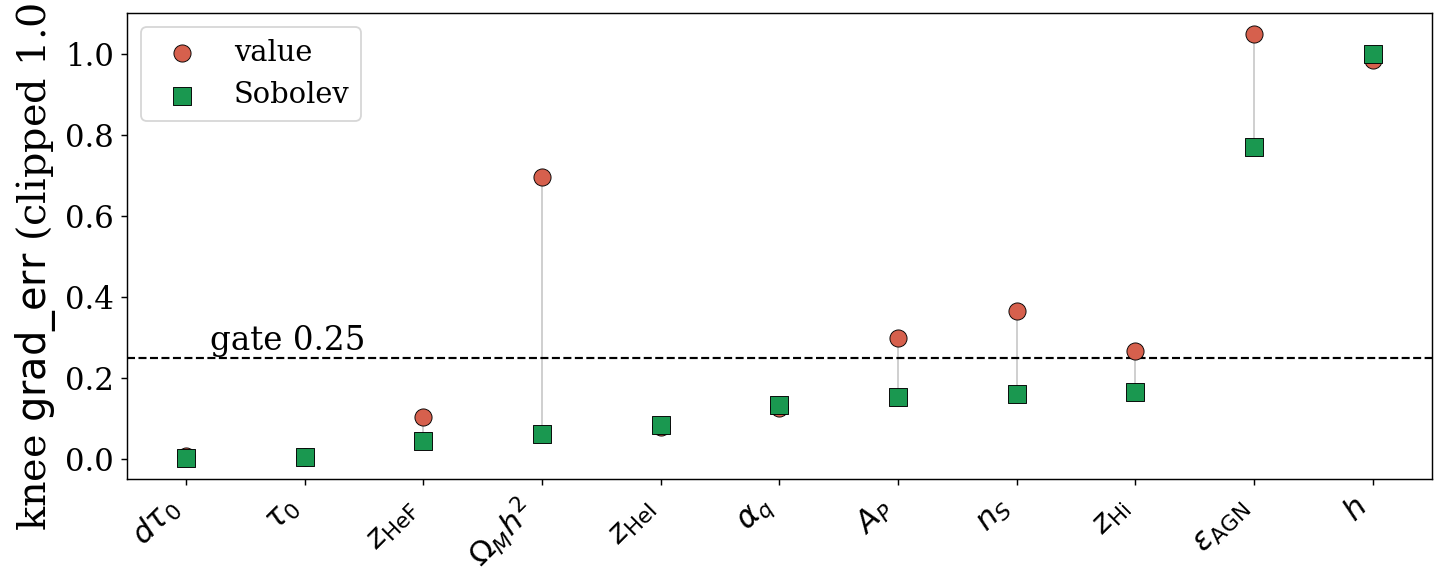

In [7]:
with pf.paper_style(usetex=False):
    show(pf.plot_scorecard(run))

## Fig `ns_budget_panel` (`fig:ns_budget`) — the n_S Mirage + maxsize=35 control

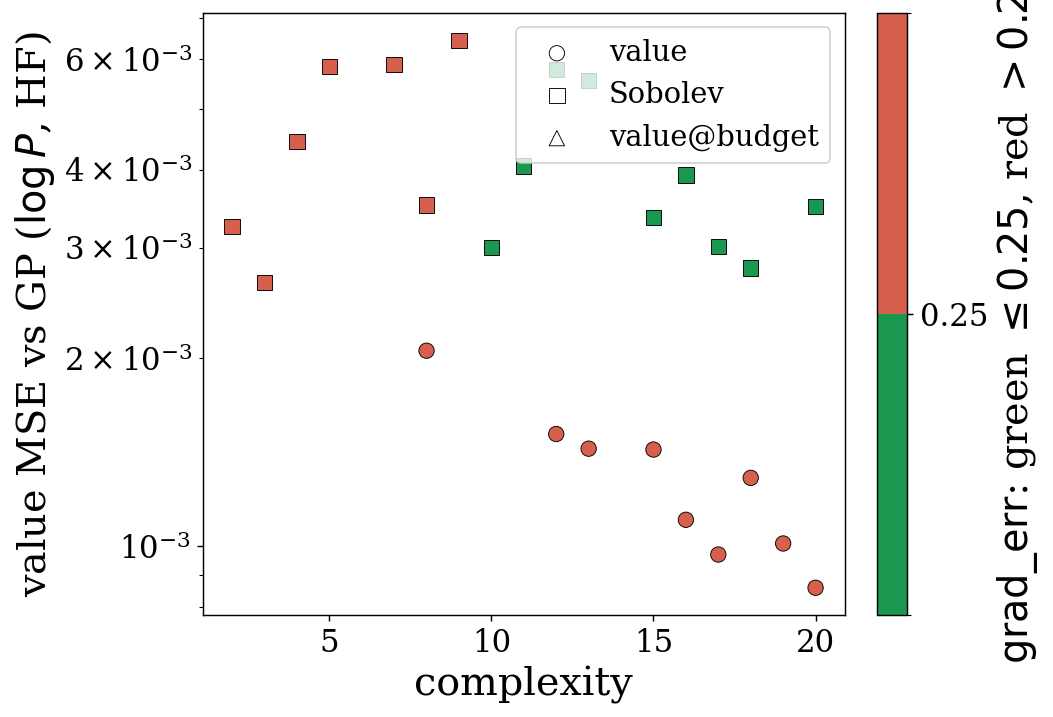

In [8]:
with pf.paper_style(usetex=False):
    show(pf.plot_ns_budget(run))

## Fig `seed_band` (`fig:seed_band`) — across-seed grad_err band

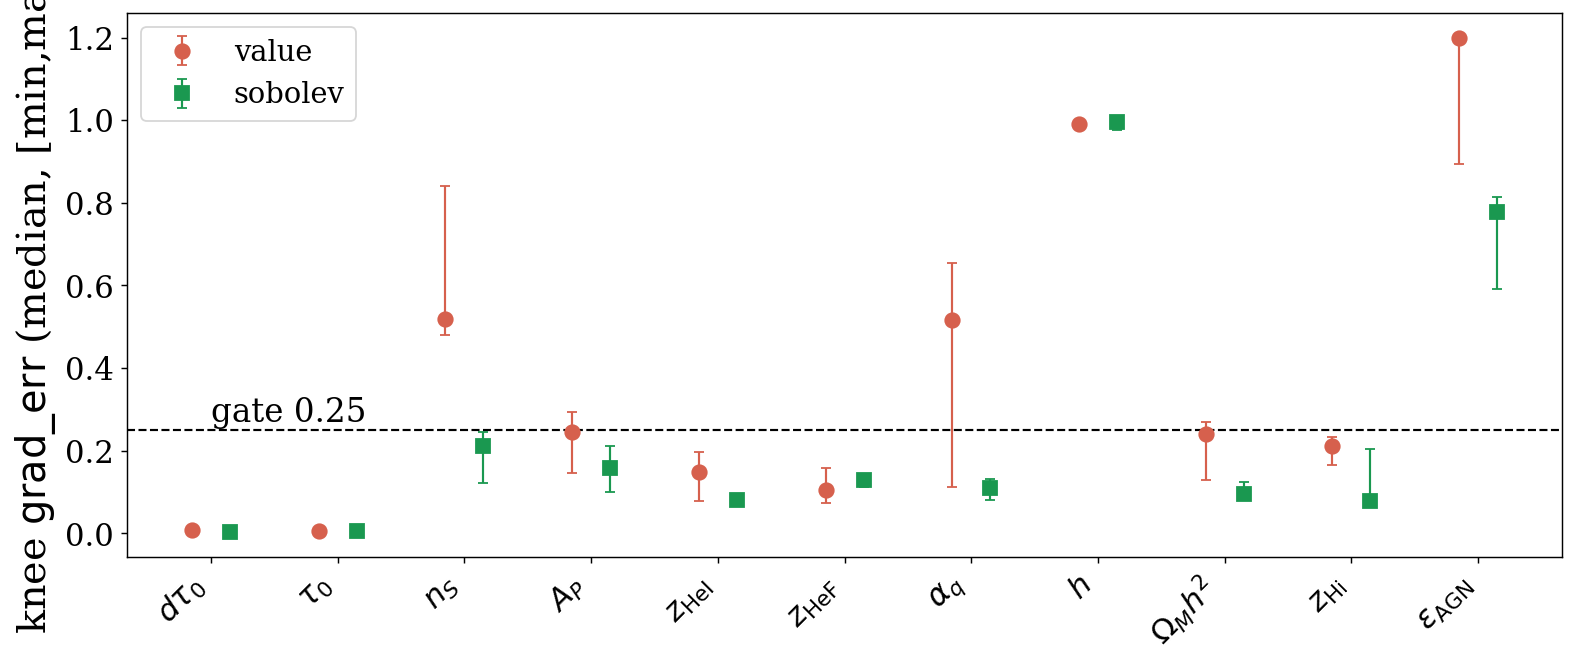

In [9]:
with pf.paper_style(usetex=False):
    show(pf.plot_seed_band(run))

---
# Tier 2 — GP-backed prediction figures + Table 3

Need the multi-fidelity GP emulator (equations are already refit+pickled; **Julia/PySR not needed**).
Each cell runs the paper's regen script if `HAVE_GP`, else prints the command.

## Fig `pysr_pred_tau0_Ap` (`fig:tau0_ap_pred`) — τ0 & Ap 1D PySR-vs-GP prediction

$ python /home/mfho/Latex/Knowledge-Distillation-using-PySR-with-PRIYA-suite/scripts/regen_fig1.py --refit-dir results/paper_production_20260630_perz_sobolev_z2.6-4.2/sobolev/refit/z3.6 --out-dir results/_repro_scratch/reproduce_paper


wrote results/_repro_scratch/reproduce_paper/pysr_pred_tau0_Ap.pdf
(showing committed reference figure)


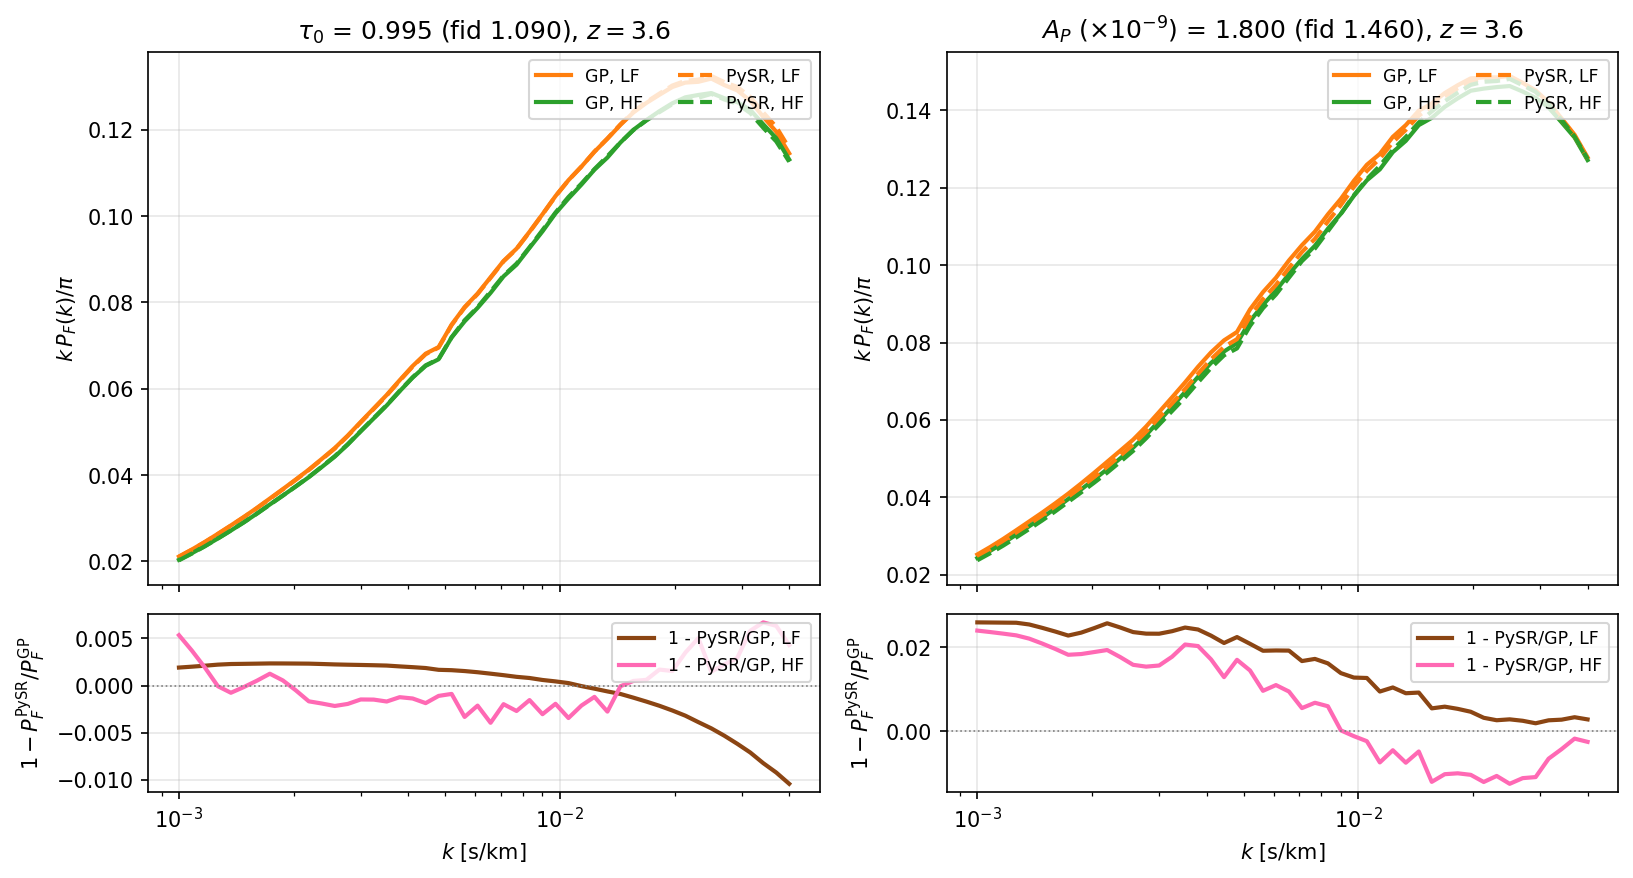

In [10]:
pdf = run_regen([FIGREPO + "/scripts/regen_fig1.py",
                 "--refit-dir", PROD / "sobolev/refit/z3.6", "--out-dir", SCRATCH],
                SCRATCH / "pysr_pred_tau0_Ap.pdf")
show_pdf(pdf, FIG / "pysr_pred_tau0_Ap.png")

## Fig `pysr_graphs_3.6_dtau0` (`fig:dtau0_p1d_pred`) — dτ0 P1D PySR-vs-GP prediction

$ python /home/mfho/Latex/Knowledge-Distillation-using-PySR-with-PRIYA-suite/scripts/regen_fig3.py --param dtau0 --z 3.6 --refit-dir results/paper_production_20260630_perz_sobolev_z2.6-4.2/sobolev/refit/z3.6 --out-dir results/_repro_scratch/reproduce_paper


wrote results/_repro_scratch/reproduce_paper/pysr_graphs_3.6_dtau0.pdf
(showing committed reference figure)


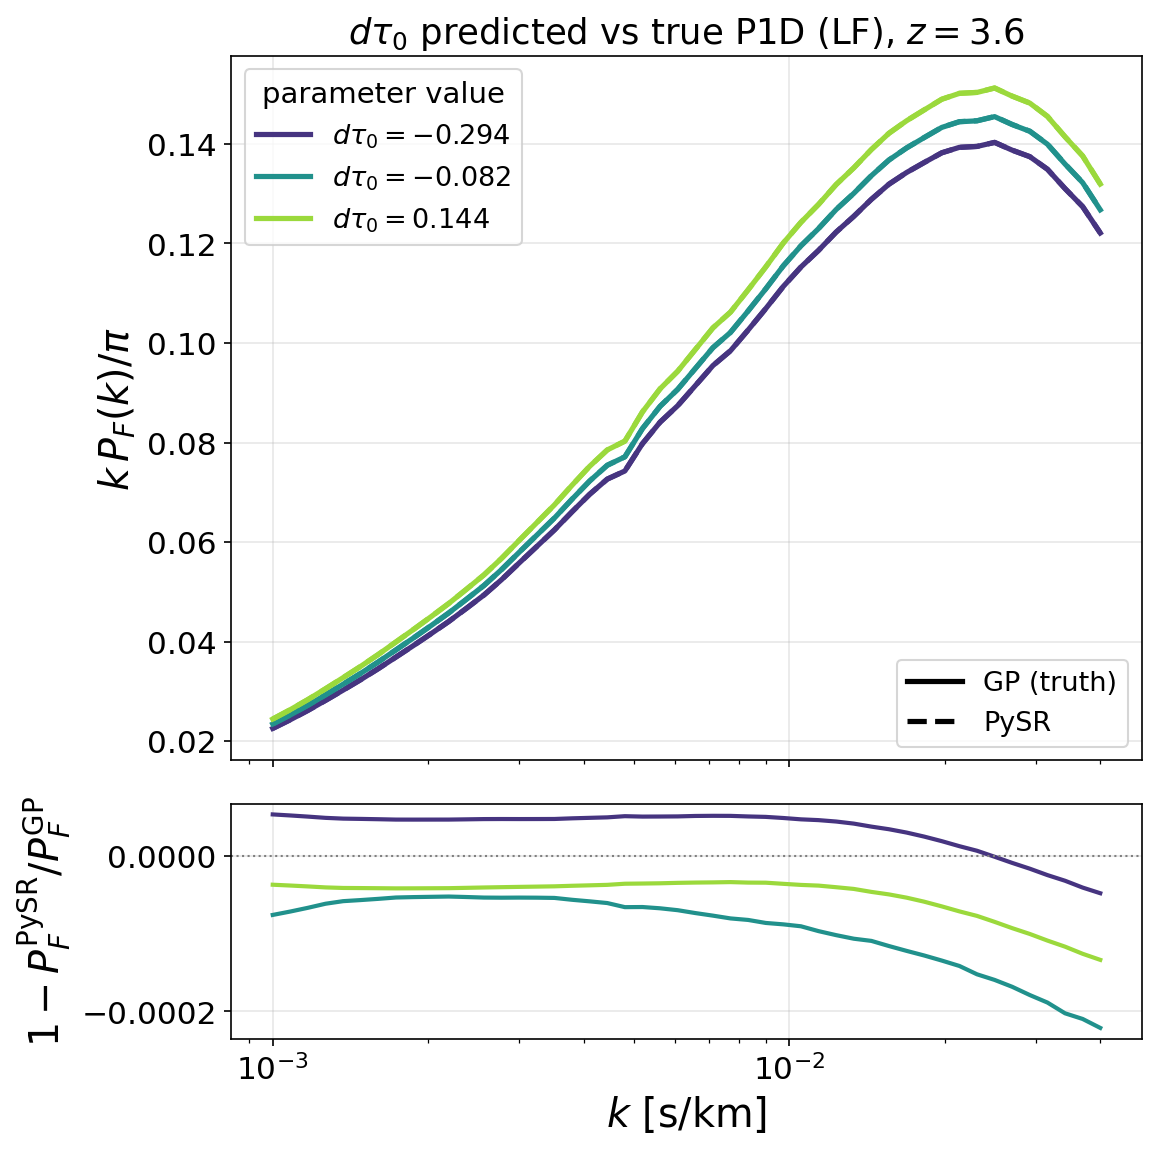

In [11]:
pdf = run_regen([FIGREPO + "/scripts/regen_fig3.py", "--param", "dtau0", "--z", "3.6",
                 "--refit-dir", PROD / "sobolev/refit/z3.6", "--out-dir", SCRATCH],
                SCRATCH / "pysr_graphs_3.6_dtau0.pdf")
show_pdf(pdf, FIG / "pysr_graphs_3.6_dtau0.png")

## Fig `multid_bestworst` (`fig:multid_bestworst`) + Table 2 backing CSV
`regen_multid` builds the 2D/3D combine error over a Sobol sample (GP-backed, slow).
`--n-sobol 64` here for speed; the committed table used 256.

$ python scripts/regen_multid.py --refit-dir results/paper_production_20260630_perz_sobolev_z2.6-4.2/sobolev --z 3.6 --basedir data/kodiaq_gp --out-dir results/_repro_scratch/reproduce_paper/multid --n-sobol 64



3D: best  = tau0-Ap-ns             mean 0.79% (p90 1.84%, max 4.39%)
3D: worst = Ap-ns-omegamh2         mean 0.92% (p90 2.12%, max 5.50%)
(showing committed reference figure)


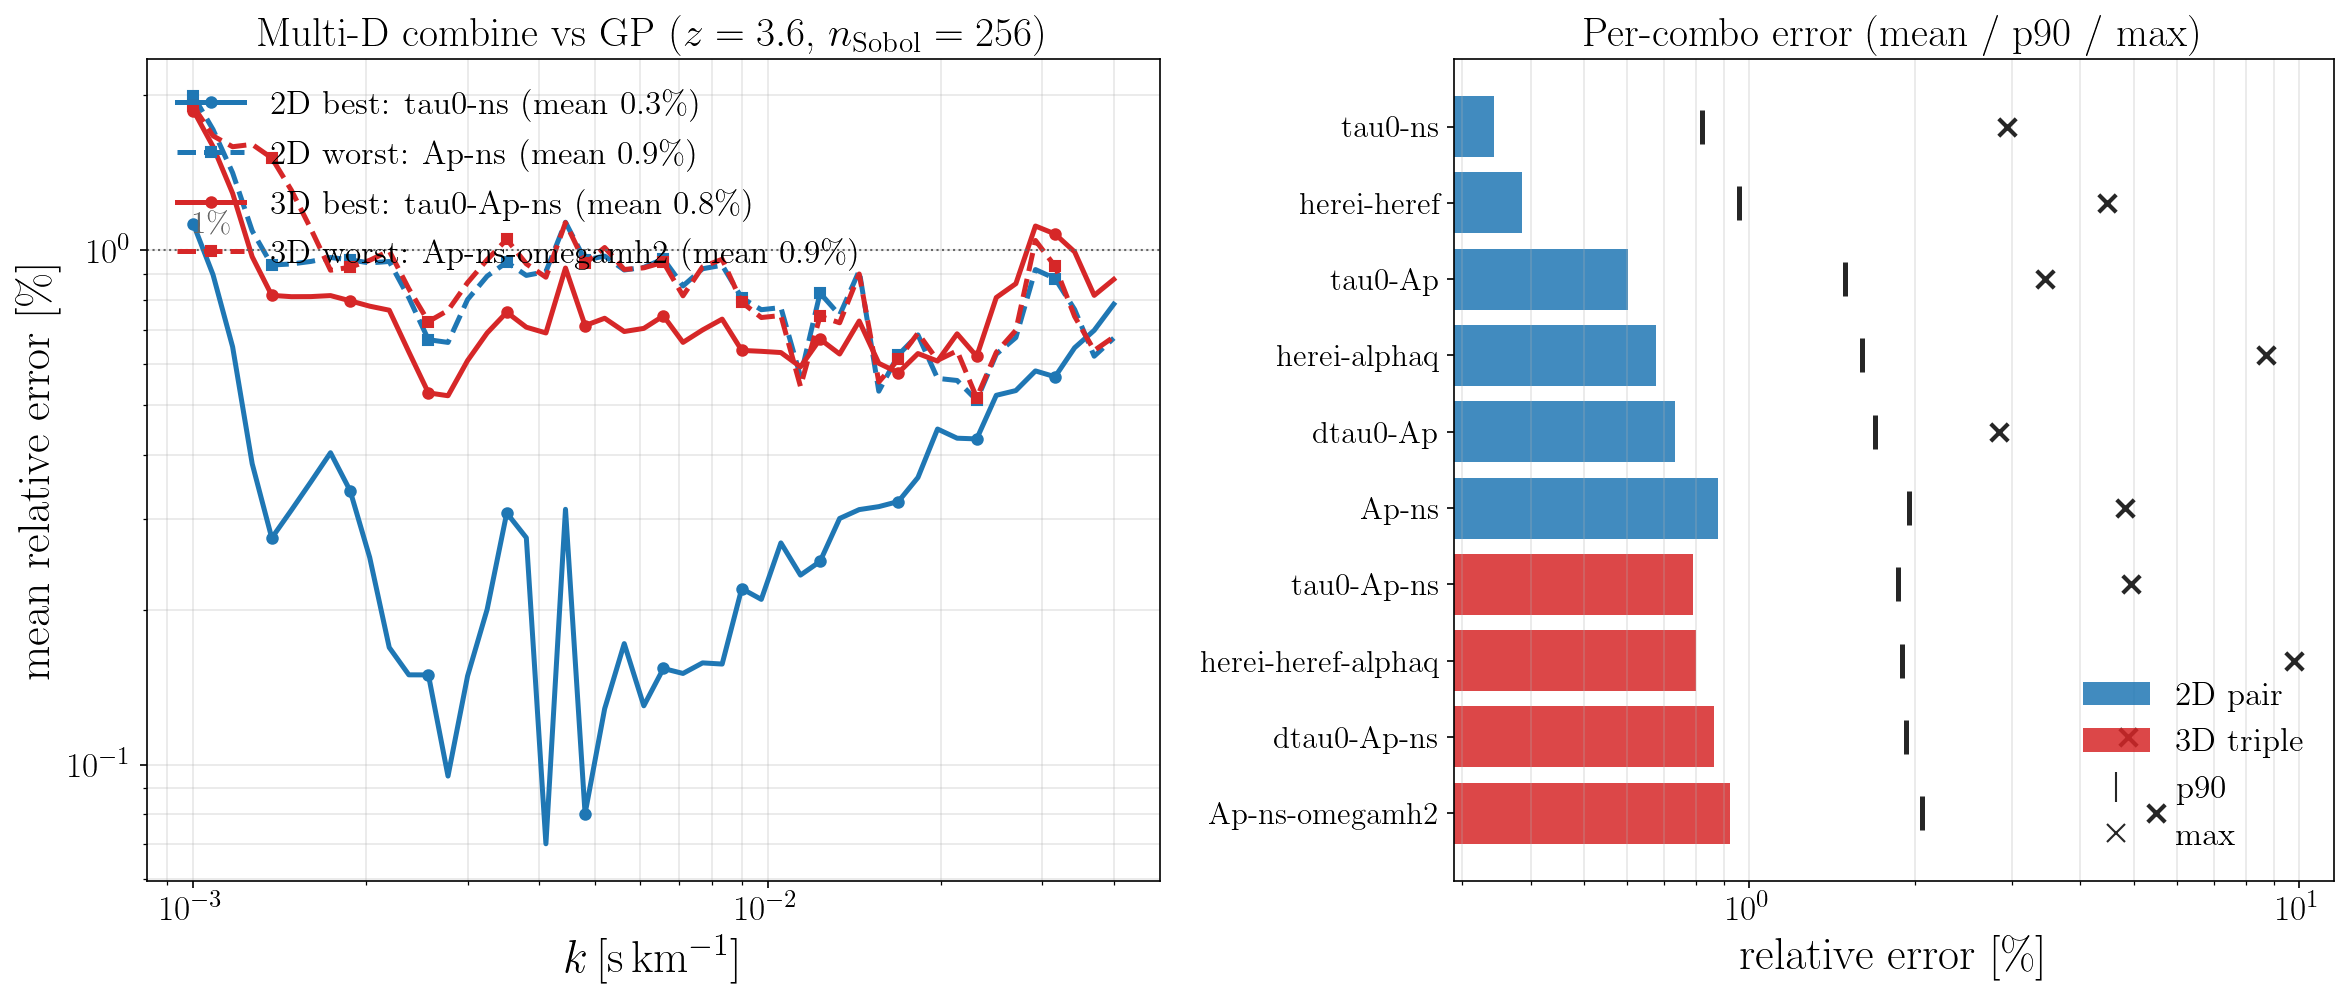

dim             params  n_varied  mean_pct  p90_pct  max_pct   max_k  gp_sliced  role
 2D           dtau0-Ap         2    0.7332   1.6846   2.8428 0.00351        NaN   NaN
 2D       herei-alphaq         2    0.6739   1.6057   8.7006 0.00100        NaN   NaN
 2D              Ap-ns         2    0.8759   1.9453   4.3271 0.00100        NaN worst
 2D            tau0-ns         2    0.3438   0.8145   2.8429 0.00100        NaN  best
 2D        herei-heref         2    0.3905   0.9478   4.4669 0.00219        NaN   NaN
 2D            tau0-Ap         2    0.5984   1.4682   3.4500 0.00351        NaN   NaN
 3D        dtau0-Ap-ns         3    0.8619   1.9067   4.3709 0.00100        NaN   NaN
 3D herei-heref-alphaq         3    0.8280   2.0178   9.7892 0.00100        NaN   NaN
 3D         tau0-Ap-ns         3    0.7924   1.8438   4.3938 0.00100        NaN  best
 3D     Ap-ns-omegamh2         3    0.9225   2.1158   5.4978 0.00127        NaN worst


In [12]:
pdf = run_regen(["scripts/regen_multid.py", "--refit-dir", PROD / "sobolev", "--z", "3.6",
                 "--basedir", GP_BASEDIR, "--out-dir", SCRATCH / "multid", "--n-sobol", "64"],
                SCRATCH / "multid" / "multid_bestworst.pdf")
show_pdf(pdf, FIG / "multid_z3.6" / "multid_bestworst.png")
_csv = SCRATCH / "multid" / "multid_bestworst.csv"
if _csv.exists():
    print(pd.read_csv(_csv, comment="#").to_string(index=False))

## Table 3 (`tab:stats_table`) — per-parameter 1D % error (LF/HF)
`regen_table2.py` recomputes it from the refit/payload pickles (GP-backed); the committed
`table2_stats.tex` is the artifact of record.

In [13]:
run_regen([FIGREPO + "/scripts/regen_table2.py",
           "--refit-dir", PROD / "sobolev/refit/z3.6", "--z", "3.6"], SCRATCH / "_none")
print("\n--- committed figures/table2_stats.tex (artifact of record) ---")
print((FIG / "table2_stats.tex").read_text())

$ python /home/mfho/Latex/Knowledge-Distillation-using-PySR-with-PRIYA-suite/scripts/regen_table2.py --refit-dir results/paper_production_20260630_perz_sobolev_z2.6-4.2/sobolev/refit/z3.6 --z 3.6


\end{tabular}
\end{ruledtabular}
\end{table}

--- committed figures/table2_stats.tex (artifact of record) ---
dtau0         LF:   0.007% (max   0.023%)   HF:   0.114% (max   0.538%)
tau0          LF:   0.221% (max   1.041%)   HF:   0.244% (max   1.213%)
ns            LF:   0.860% (max   5.299%)   HF:   5.160% (max  10.782%)
Ap            LF:   1.636% (max   4.490%)   HF:   1.182% (max   4.490%)
herei         LF:   0.107% (max   0.808%)   HF:   0.285% (max   1.362%)
heref         LF:   0.588% (max   2.768%)   HF:   1.071% (max   7.410%)
alphaq        LF:   1.240% (max   1.946%)   HF:   1.464% (max   3.176%)
hub           LF:   0.209% (max   1.721%)   HF:   1.678% (max  10.504%)
omegamh2      LF:   0.167% (max   2.015%)   HF:   1.157% (max   5.279%)
hireionz      LF:   0.099% (max   1.281%)   HF:   1.610% (max   7.762%)
bhfeedback    LF:   0.104% (max   1.199%)   HF:   0.377% (max   2.090%)

--- LaTeX ---
\begin{table}[!h]
\caption{\label{tab:stats_table} Mean and maximum relative percen

---
# Appendix — regenerable figures not in the compiled paper

These two floats are commented out in the current `.tex` (dropped by the author), but their
data is valid and they regenerate emulator-free — included here for completeness.

## Fig `maxsize_sensitivity` (`fig:maxsize_sens`, commented) — search budget vs objective
Value-loss faithfulness falls with the maxsize budget (and is seed-fragile); Sobolev is
already faithful at maxsize=20. The numbers survive in §4.4 even though the figure is dropped.

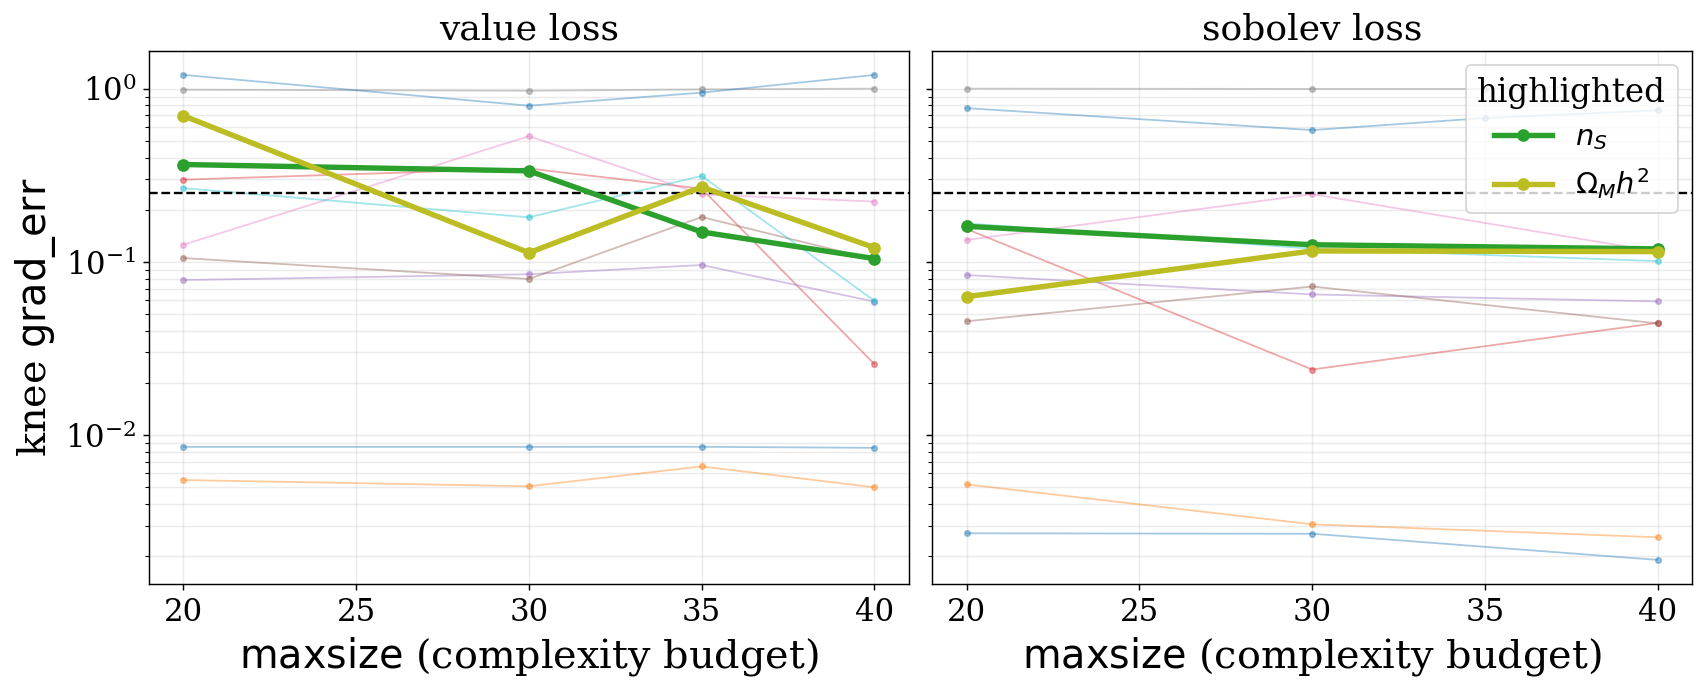

In [14]:
with pf.paper_style(usetex=False):
    show(pf.plot_maxsize_sensitivity(run))

## Fig `crossz_faithfulness` (`fig:crossz`, commented) — z=2.6/3.6/4.2 robustness
Per-z faithful counts 8/9/6 at z=2.6/3.6/4.2; five params faithful at all three; the He II
reion block blows up at z=4.2. Regenerated from the committed cross-z Sobolev sidecars.

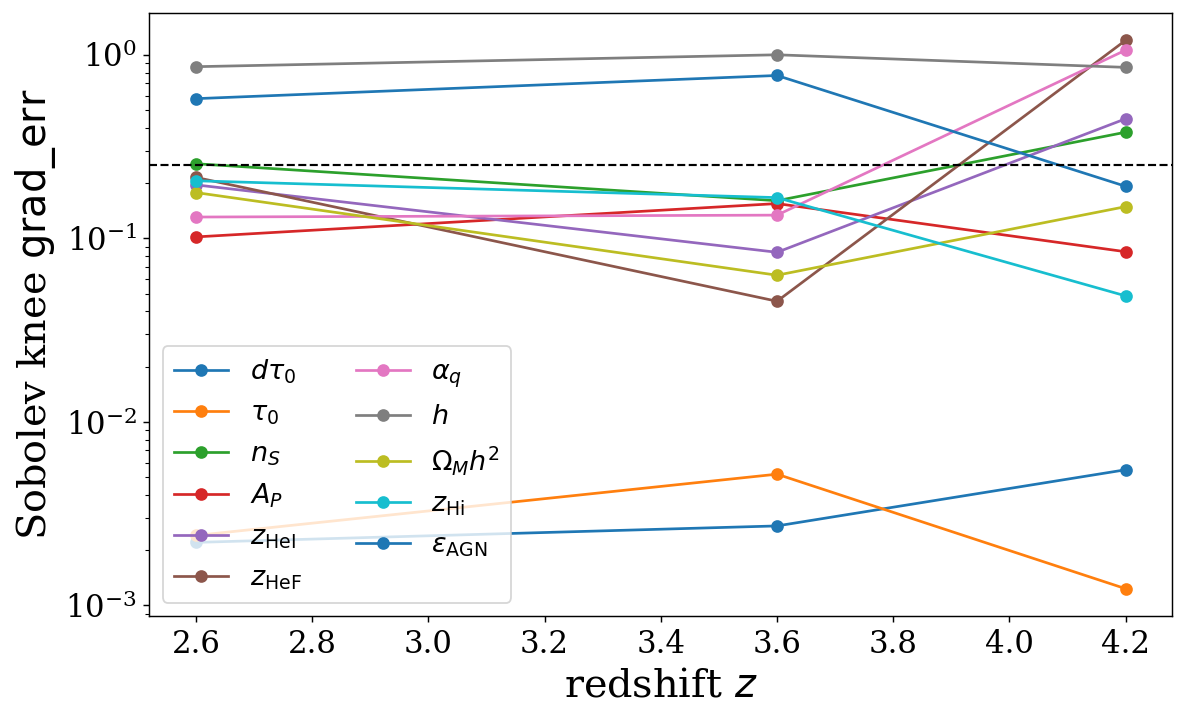

In [15]:
with pf.paper_style(usetex=False):
    show(pf.plot_crossz(run))

---
## Figure/table → `\label` → section map

| paper | `\label` | tier |
|-------|----------|:----:|
| Table 1 | `tab:param_table` | 1 |
| Table 2 | `tab:multid` | 1 read / 2 regen |
| Table 3 | `tab:stats_table` | 2 |
| Table 6 | `tab:faith_taxonomy` | 1 |
| Table 7 | `tab:per1d_eqs` | 1 |
| Fig `pareto_faithfulness` | `fig:pareto_faith` | 1 |
| Fig `faithfulness_scorecard` | `fig:faith_scorecard` | 1 |
| Fig `ns_budget_panel` | `fig:ns_budget` | 1 |
| Fig `seed_band` | `fig:seed_band` | 1 |
| Fig `pysr_pred_tau0_Ap` | `fig:tau0_ap_pred` | 2 |
| Fig `pysr_graphs_3.6_dtau0` | `fig:dtau0_p1d_pred` | 2 |
| Fig `multid_bestworst` | `fig:multid_bestworst` | 2 |

*Commented-out floats* (`holdout_validation`, `2d-denorm-Sobol_dtau0-Ap`,
`maxsize_sensitivity`, `crossz_faithfulness`) are not in the compiled paper;
`pf.plot_maxsize_sensitivity(run)` / `pf.plot_crossz(run)` still regenerate the last two.

## Tweak any figure
Every `pf.plot_*` returns a Matplotlib `Figure`; restyle with `pf.paper_style(usetex=…, scale=…)`
or edit the returned object; recolour via `pf.C_VALUE` / `pf.C_SOBOLEV`. Point
`pf.load_run("results/other_run")` at a different run to regenerate everything on new data.